# Managing Experiments

We here describe the typical workflow to work with large microscopy image datasets using SpheroidPy. Throughout this section, we assume that the package has been imported using `import SpheroidPy`.

If `SpheroidPy` is not installed on your system yet, we have to import its folder to the Python module search path:

In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../SpheroidPy')

## __Setting up a new Experiment__

Text

To create a new experiment instance, a name, the number of wells (e.g., 96 or 384), and the path to the project folder need to be specified. The path will be used to store ..

In [5]:
from SpheroidPy.experiment import Experiment # import class
from pathlib import Path                     # for path management

my_experiment = Experiment(name='ExperimentName', layout=96, path=Path('example_data'))

In order to continue working on a previous experiment its data and structure can be easily reloaded.

In [7]:
#loaded_experiment = Experiment.from_file('example_data/ExperimentName/Experiment_ExperimentName_data.h5')

This will restore the complete experiment context, including results, metadata, and settings.

## __Result__

Text

In [10]:
from SpheroidPy.experiment import Result
my_result = my_experiment.result('Result Name')

#### __Managing a Platemap__

… A platemap defines the experimental setup for each well, such as cell lines, compound treatments, and its concentrations. To assign a new cell line to the result or modify the values of an existing cell line one can use

Output()

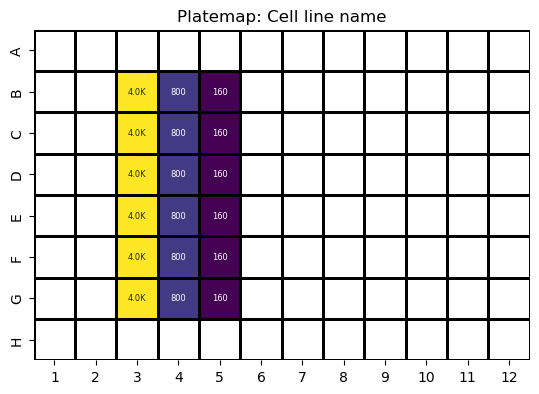

In [12]:
#my_result.platemap.cell_line('Cell line name')
# or to directly define multiple concentrations across specific well ranges:
my_result.platemap.cell_line('Cell line name', 
                             {4000: 'B3:G3', 800: 'B4:G4', 160: 'B5:G5'})

#### __Loading Data & Segmentation__

Text ...

In [14]:
my_result.load_images('example_data/',
                      ['PhaseContrast','raw'], # array of str that label files of each channel
                      ['fluorescence','green'],['fluorescence','red'], 
                      image_size=(1700,1270)) # image size (µm) in x- and y-direction

Looking for Wells: ['B3', 'C3', 'D3', 'B4', 'C4', 'D4', 'B5', 'C5', 'D5']


Loading wells: 100%|██████████| 9/9 [00:04<00:00,  1.87it/s]


Images have been loaded successfully!


In [15]:
my_result.segmentation([
        ('thresholding', 'fluorescence_green'),
        ('ai', 'brightfield')
    ], threshold=1.15, confidence=0.7, reconstruct_border=True, border_margin=20)

Processing segmentation: 100%|██████████| 9/9 [00:18<00:00,  2.07s/it]



Segmentation complete:
Successfully segmented 69/69 images


(('Cell line name', 4000),)            (('Cell line name', 800),)  \
                             mean        std                       mean   
0.0                    453.392614  17.897777                 237.882382   
48.0                   201.086044   5.302840                 117.261590   
96.0                   267.099737   6.667915                 183.102707   
144.0                  344.377313   6.372396                 266.332900   
192.0                  407.674296   3.817246                 341.417468   
240.0                  469.998658   1.693088                 396.540461   
288.0                  494.131692   2.387292                 439.603473   
336.0                  608.784295  85.163353                 495.732410   

                 (('Cell line name', 160),)             
             std                       mean        std  
0.0     5.818881                  94.068584  70.336089  
48.0    3.348805                  98.972490  60.115908  
96.0    3.708265                 129.578110  30.779580  
144.0   2.258599                 189.113301  10.022711  
192.0   4.025682                 269.501932   7.971179  
240.0   4.170819                 331.984370   4.013447  
288.0   0.000000                 394.354765   5.007808  
336.0  20.184545                 437.085054  25.504221

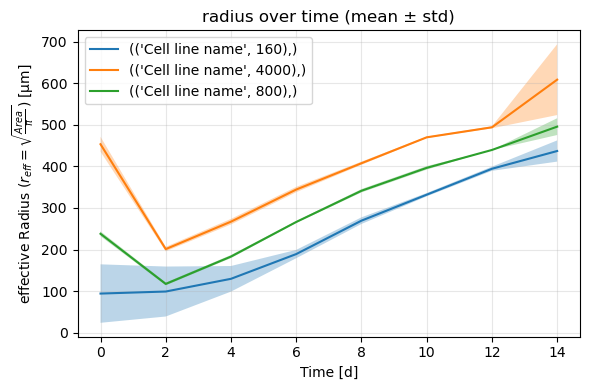

In [16]:
my_result.metric('radius', plot=True, mean=True)

#### __Visualising the Data__

The experiment comes with a built-in visualization tool. Use the interactive interface to explore your data, inspect segmentation results, and review per-well or aggregate metrics:

In [18]:
my_experiment.visualisation.interactive()

#### __Managing multiple Results__

The Experiment class is designed to handle multiple results under a single experimental umbrella. This allows you to compare data across time points, treatments, or different image acquisitions.

You can access and iterate over all associated results:

In [20]:
my_2nd_result = experiment.result('Result Name 2')

NameError: name 'experiment' is not defined

## __Analyses__

Text

To create a new experiment instance, a name, the number of wells (e.g., 96 or 384), and the path to the project folder need to be specified. The path will be used to store ..

In [ ]:
from SpheroidPy.experiment import Analysis
my_result = experiment.analysis('Analysis Name')